# Análisis Exploratorio de Datos (EDA) - Retención B2B / Churn
**Objetivo de Negocio:** Identificar qué clientes presentan la mayor probabilidad de cancelar su suscripción en el corto plazo y qué factores operativos influyen más en esa decisión, para focalizar las estrategias de retención.

In [1]:
# 1. IMPORTACIONES Y CONFIGURACIÓN VISUAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo ejecutivo limpio
sns.set_theme(style="whitegrid")

# Paleta Corporativa
color_navy = "#1F4E79"       # Principal
color_charcoal = "#363636"   # Secundario (textos, bordes)
color_coral = "#F16A70"      # Acento (Fuga / Riesgo)
color_lightblue = "#8ECAE6"  # Soporte visual

# Paleta específica para la variable objetivo (Churn)
palette_churn = {"No": color_navy, "Yes": color_coral}

# Configuración global de fuentes
plt.rc('axes', titlesize=14, labelsize=11, titleweight='bold', labelcolor=color_charcoal)
plt.rc('xtick', labelsize=10, color=color_charcoal)
plt.rc('ytick', labelsize=10, color=color_charcoal)

In [2]:
# 2. CARGA DE DATOS Y LIMPIEZA
# CORRECCIÓN: Como el archivo es .xlsx, se debe usar read_excel en lugar de read_csv
file_path = 'Telco-Churn.xlsx'

df = pd.read_excel(file_path)

# Correcciones iniciales de formato
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str).map({'0': 'No', '1': 'Yes'})

# Diagnóstico
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Valores Nulos encontrados:")
print(nulos if not nulos.empty else "No se encontraron valores nulos.")

duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}\n")

# Imputación rápida de nulos (TotalCharges para clientes nuevos)
df['TotalCharges'].fillna(0, inplace=True)

# Separar variables por tipo para análisis automatizado (excluyendo IDs)
df_clean = df.drop(columns=['customerID'])
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn') # Separar el target

Dimensiones del dataset: 7043 filas y 21 columnas.

Valores Nulos encontrados:
TotalCharges    11
dtype: int64

Filas duplicadas: 0




Estadísticas Descriptivas (Variables Numéricas):


,mean,50%,std,skewness,kurtosis
tenure,32.371149,29.000,24.559481,0.239540,-1.387372
MonthlyCharges,64.761692,70.350,30.090047,-0.220524,-1.257260
TotalCharges,2283.300441,1397.475,2266.771362,0.961642,-0.231799


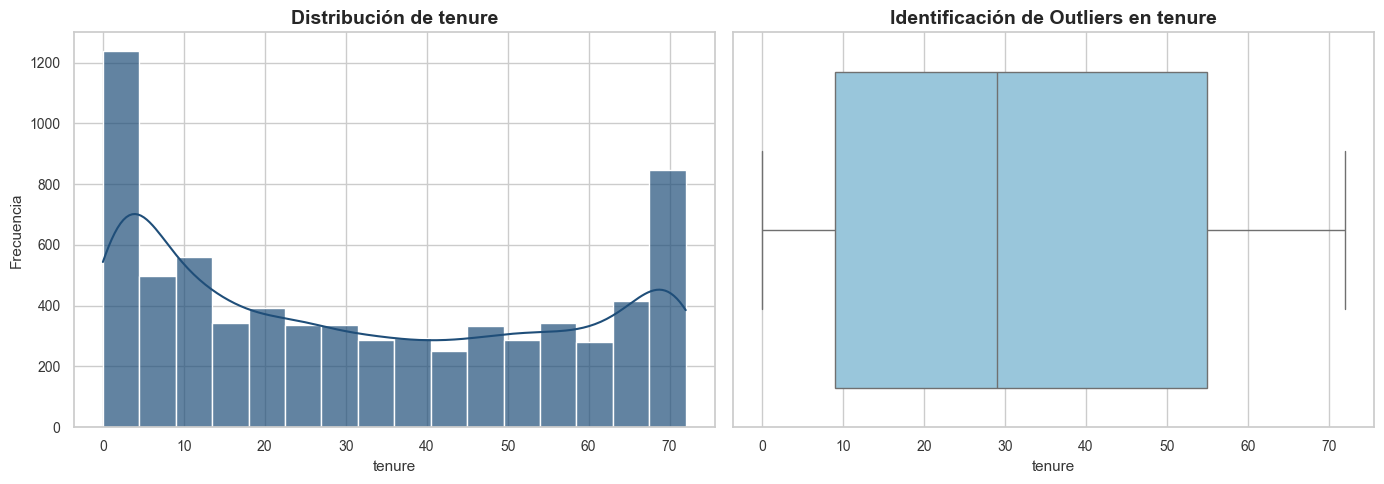

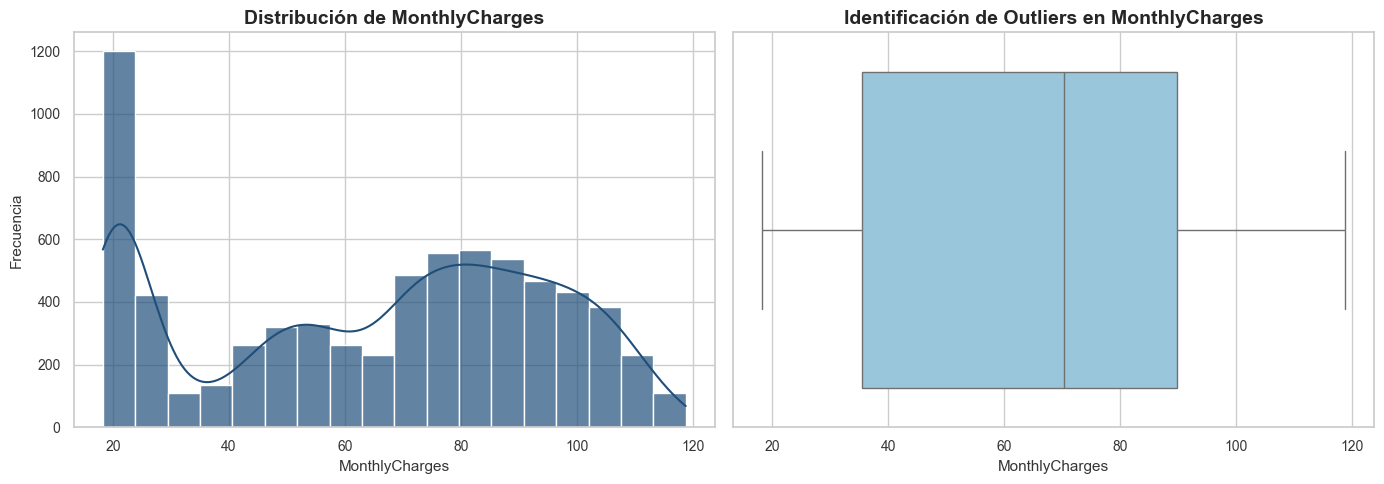

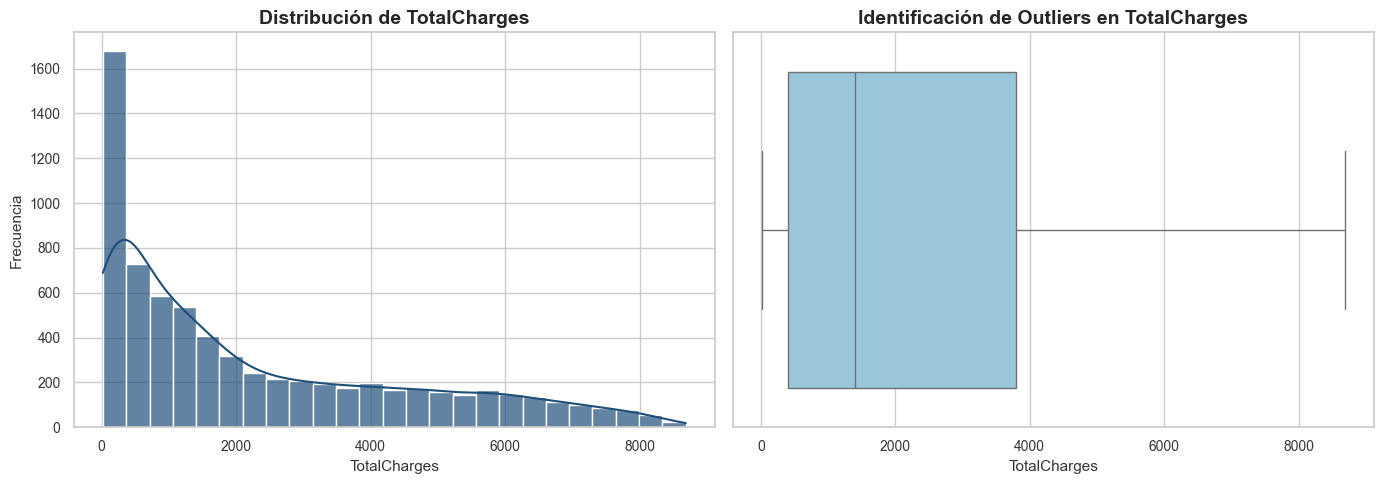

In [3]:
# 3A. ANÁLISIS UNIVARIADO: NUMÉRICAS
print("\nEstadísticas Descriptivas (Variables Numéricas):")
desc_stats = df[num_cols].describe().T
desc_stats['skewness'] = df[num_cols].skew()
desc_stats['kurtosis'] = df[num_cols].kurtosis()
display(desc_stats[['mean', '50%', 'std', 'skewness', 'kurtosis']])

# Gráficos de Distribución (Histograma + KDE y Boxplot)
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    sns.histplot(df[col], kde=True, color=color_navy, ax=axes[0], alpha=0.7)
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot
    sns.boxplot(x=df[col], color=color_lightblue, ax=axes[1], fliersize=4)
    axes[1].set_title(f'Identificación de Outliers en {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

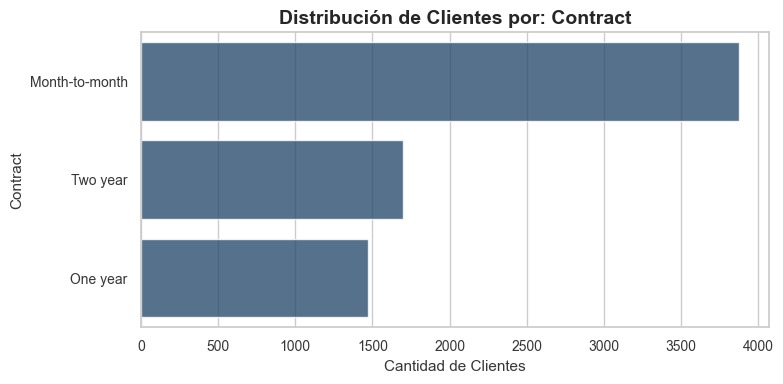

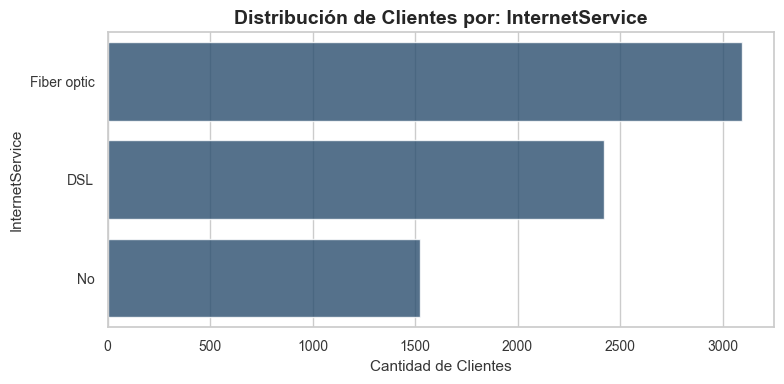

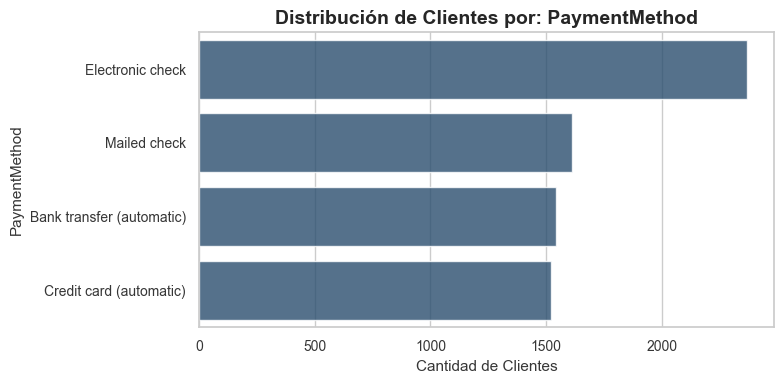

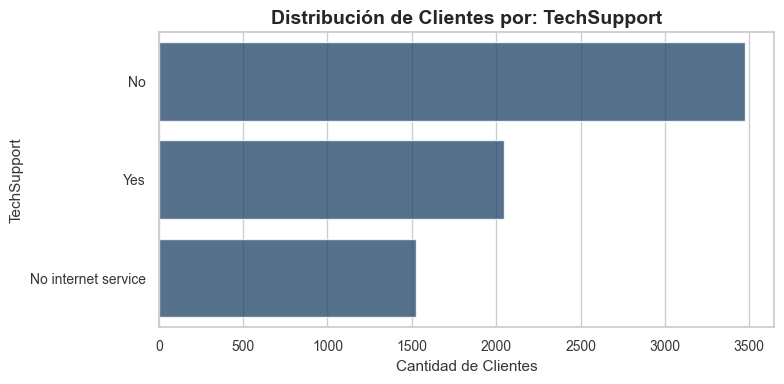

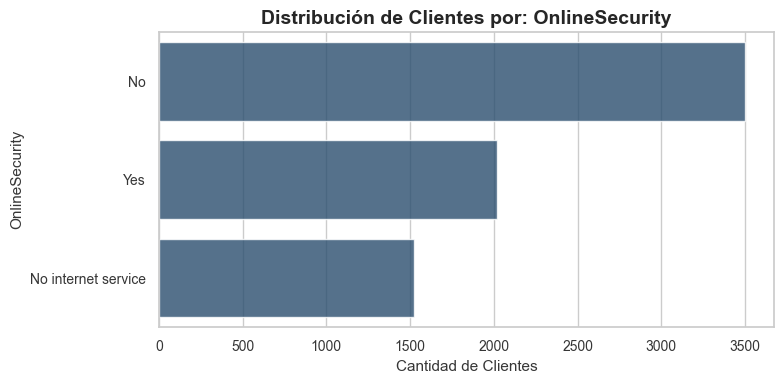

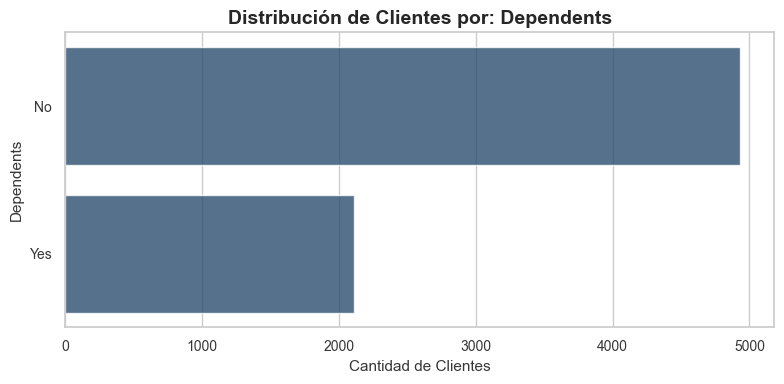

In [4]:
# 3B. ANÁLISIS UNIVARIADO: CATEGÓRICAS (Top operativas)
cols_b2b_operativas = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'Dependents']

for col in cols_b2b_operativas:
    plt.figure(figsize=(8, 4))
    
    # Ordenar por frecuencia
    order = df[col].value_counts().index
    
    sns.countplot(y=col, data=df, order=order, color=color_navy, alpha=0.8)
    plt.title(f'Distribución de Clientes por: {col}')
    plt.xlabel('Cantidad de Clientes')
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

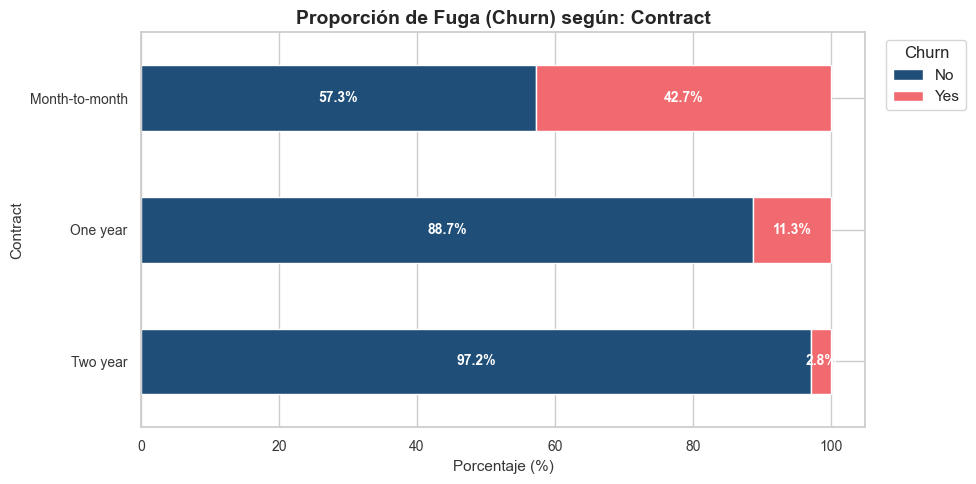

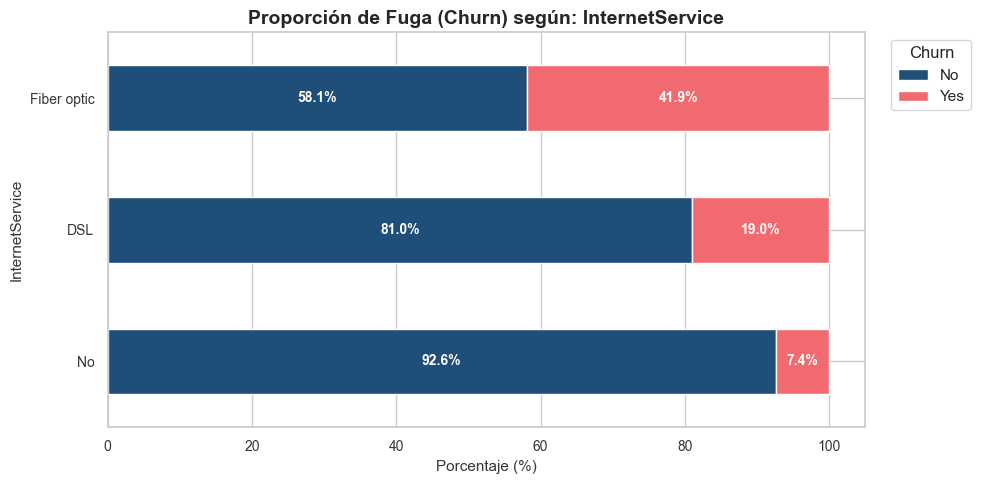

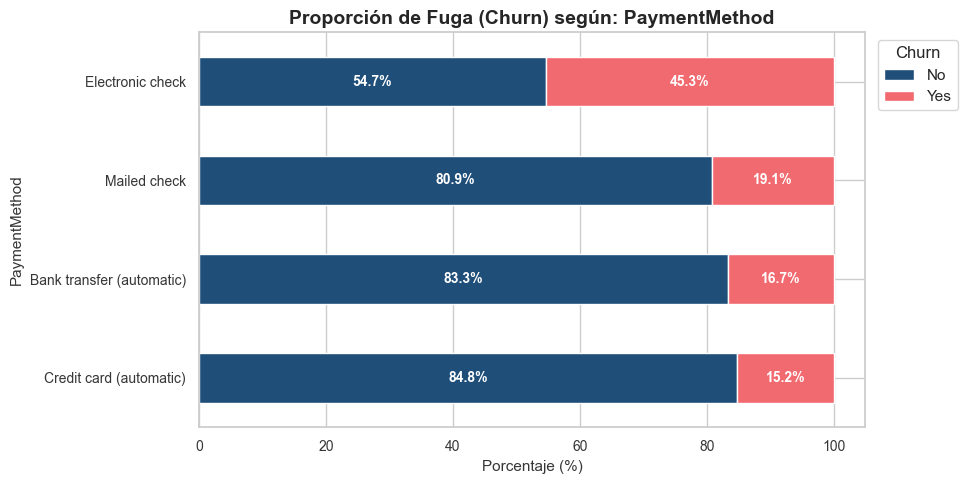

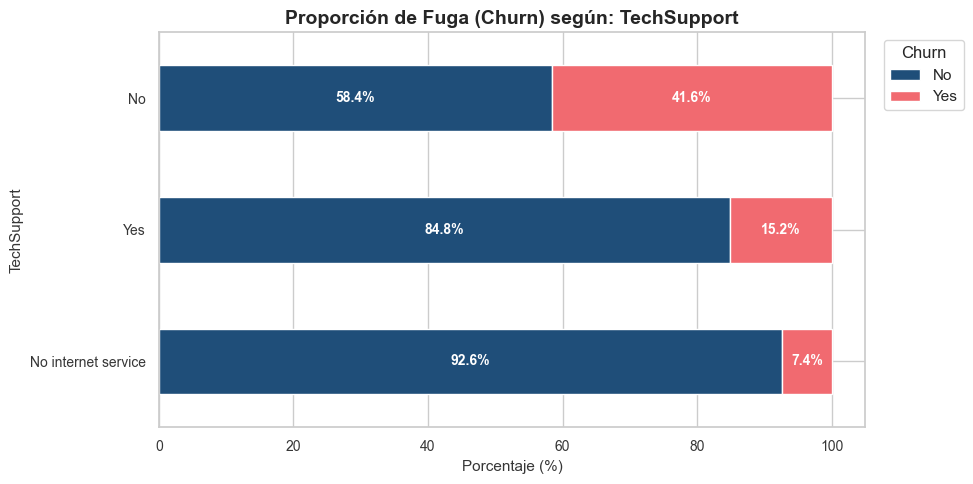

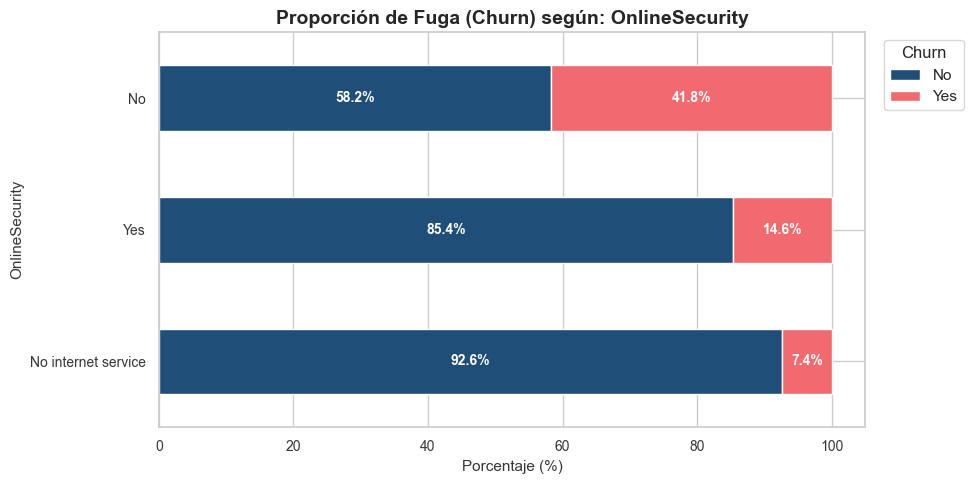

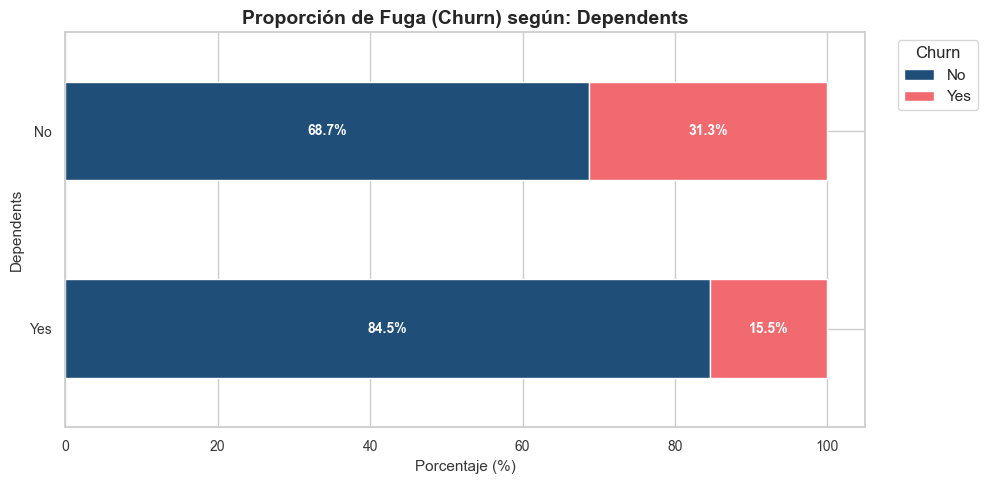

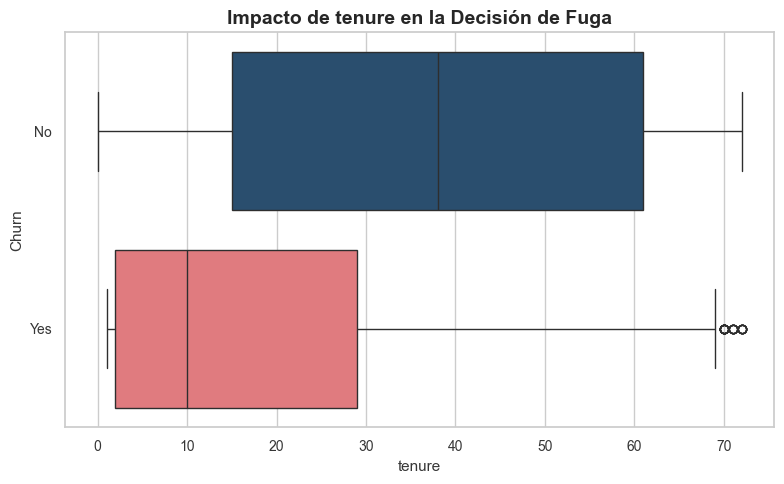

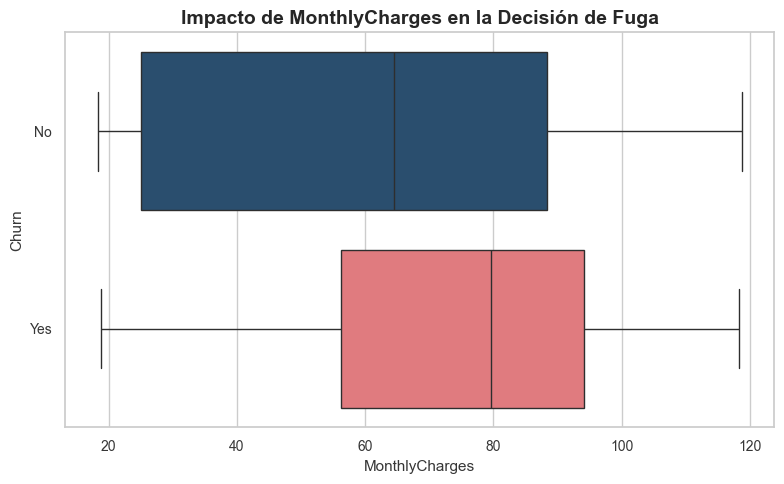

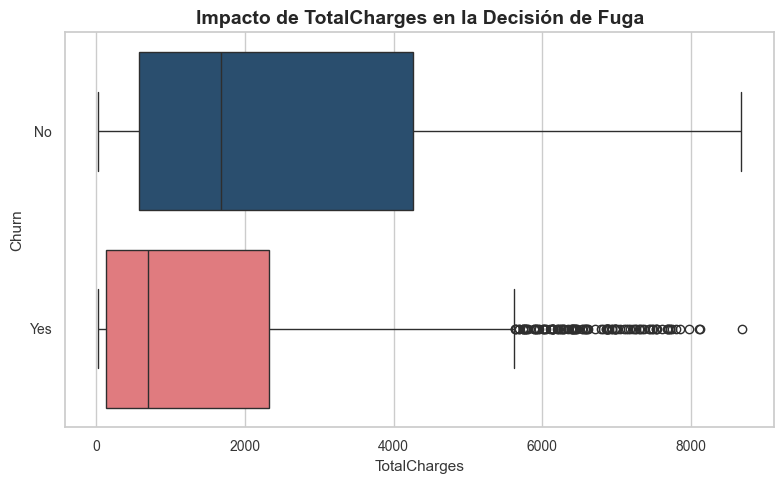

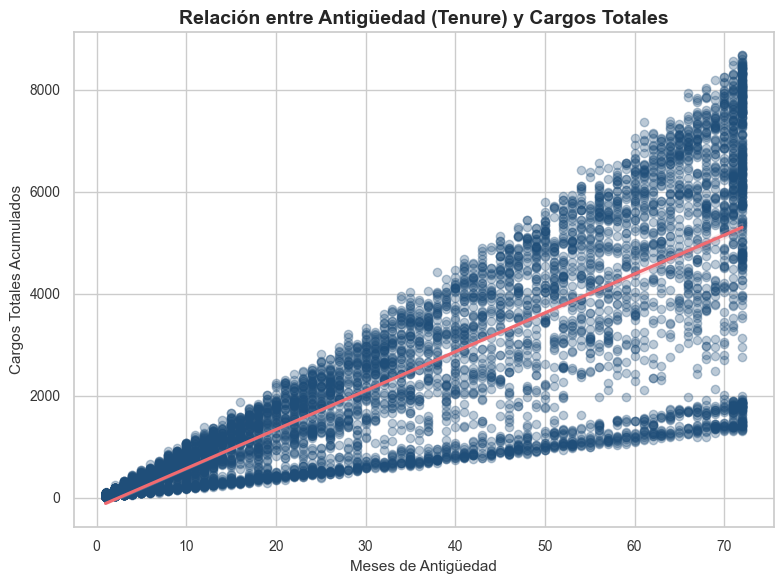

In [5]:
# 4A. CATEGÓRICA vs TARGET (Barras Apiladas 100%)
for col in cols_b2b_operativas:
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    crosstab = crosstab.sort_values(by='Yes', ascending=True)
    
    ax = crosstab.plot(kind='barh', stacked=True, figsize=(10, 5), color=[color_navy, color_coral])
    
    plt.title(f'Proporción de Fuga (Churn) según: {col}')
    plt.xlabel('Porcentaje (%)')
    plt.ylabel(col)
    plt.legend(title='Churn', loc='upper right', bbox_to_anchor=(1.15, 1))
    
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=10, weight='bold')
        
    plt.tight_layout()
    plt.show()

# 4B. NUMÉRICA vs TARGET
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='Churn', data=df, palette=palette_churn, orient='h')
    plt.title(f'Impacto de {col} en la Decisión de Fuga')
    plt.xlabel(col)
    plt.ylabel('Churn')
    plt.tight_layout()
    plt.show()

# 4C. NUMÉRICA vs NUMÉRICA
plt.figure(figsize=(8, 6))
sns.regplot(x='tenure', y='TotalCharges', data=df, 
            scatter_kws={'alpha':0.3, 'color': color_navy}, 
            line_kws={'color': color_coral})
plt.title('Relación entre Antigüedad (Tenure) y Cargos Totales')
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Cargos Totales Acumulados')
plt.tight_layout()
plt.show()

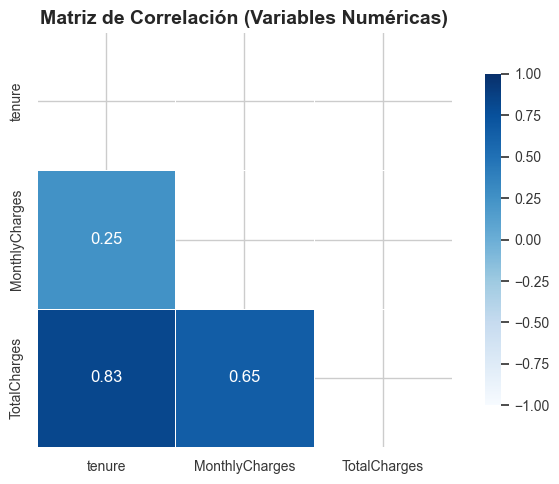


Análisis de Outliers (Método IQR):
Variable 'tenure': 0 outliers detectados.
Variable 'MonthlyCharges': 0 outliers detectados.
Variable 'TotalCharges': 0 outliers detectados.


In [6]:
# 5A. Matriz de Correlación (Solo Numéricas)
plt.figure(figsize=(7, 5))
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="Blues", 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.tight_layout()
plt.show()

# 5B. Identificación formal de Outliers mediante IQR
print("\nAnálisis de Outliers (Método IQR):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Variable '{col}': {len(outliers)} outliers detectados.")